In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../Dataset/processed/final_dataset.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"Missing: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

Shape: 9,132 rows × 52 columns
Memory: 3.80 MB
Missing: 0
Duplicates: 0


In [2]:
summary = pd.DataFrame({
    'dtype'  : df.dtypes,
    'nulls'  : df.isnull().sum(),
    'unique' : df.nunique(),
    'mean'   : df.mean(numeric_only=True),
    'std'    : df.std(numeric_only=True),
    'min'    : df.min(numeric_only=True),
    'max'    : df.max(numeric_only=True),
})
summary['null_%'] = (summary['nulls'] / len(df) * 100).round(2)
pd.set_option('display.max_rows', 60)
summary

,dtype,nulls,unique,mean,std,min,max,null_%
temperature,float64,0,2265,2.554925e+01,5.171753e+00,7.860000e+00,4.136000e+01,0.0
humidity,float64,0,4659,6.805342e+01,1.795815e+01,7.190000e+00,9.567000e+01,0.0
solar_radiation,float64,0,2146,1.708817e+01,5.208952e+00,9.800000e-01,2.946000e+01,0.0
rainfall_mm,float64,0,106,6.963585e-01,2.868062e-01,-1.790700e+00,1.623830e+00,0.0
soil_moisture_clean,float64,0,1,5.018966e-17,3.192596e-30,5.018966e-17,5.018966e-17,0.0
water_level,float64,0,39,6.843473e+01,4.411615e+01,0.000000e+00,1.000000e+02,0.0
N,float64,0,8,1.824100e+02,3.376117e+00,1.780000e+02,1.850000e+02,0.0
P,float64,0,8,1.885162e+02,1.930689e+00,1.856769e+02,1.900000e+02,0.0
K,float64,0,7,1.588879e+02,1.447573e+00,1.570000e+02,1.600000e+02,0.0
npk_sum,float64,0,8,5.298142e+02,6.752957e+00,5.210000e+02,5.350000e+02,0.0


In [3]:
frozen_cols = df.columns[df.std(numeric_only=True) < 1e-10].tolist()
print(f"Found {len(frozen_cols)} near-zero variance columns:")
for c in frozen_cols:
    print(f"  {c:40s}  std={df[c].std():.2e}  mean={df[c].mean():.2e}")

Found 23 near-zero variance columns:
  soil_moisture_clean                       std=3.19e-30  mean=5.02e-17
  bulk_density                              std=2.44e-29  mean=4.65e-16
  organic_matter_pct                        std=2.21e-29  mean=1.51e-16
  cation_exchange_capacity                  std=7.72e-30  mean=5.01e-17
  salinity_ec                               std=2.52e-29  mean=-2.86e-16
  buffering_capacity                        std=3.38e-29  mean=1.79e-16
  soil_ph_clean                             std=5.92e-29  mean=-3.74e-16
  nitrogen_ppm                              std=3.16e-30  mean=1.40e-16
  phosphorus_ppm                            std=1.25e-28  mean=7.62e-16
  potassium_ppm                             std=1.44e-29  mean=4.66e-16
  fertility_index                           std=1.02e-28  mean=1.04e-15
  nutrient_total                            std=3.47e-29  mean=4.67e-16
  np_ratio                                  std=7.82e-29  mean=7.32e-16
  nk_ratio               

In [4]:
print("Target value counts:")
print(df['target'].value_counts())
print(f"\nTarget is constant: {df['target'].nunique() == 1}")

Target value counts:
target
1    9132
Name: count, dtype: int64

Target is constant: True


In [5]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
non_frozen   = [c for c in numeric_cols if c not in frozen_cols]

outlier_report = []
for col in non_frozen:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 3*IQR) | (df[col] > Q3 + 3*IQR)).sum()
    outlier_report.append({'column': col, 'n_outliers': n_out, 'pct': round(n_out/len(df)*100, 2)})

outlier_df = pd.DataFrame(outlier_report).sort_values('n_outliers', ascending=False)
outlier_df[outlier_df['n_outliers'] > 0]

,column,n_outliers,pct
16,climate_score,404,4.42
3,rainfall_mm,312,3.42
11,fan_active,280,3.07
23,fungal_risk,171,1.87
12,irrigation_active,52,0.57
13,irrigation_events,52,0.57
17,water_efficiency,8,0.09


In [6]:
# Drop all frozen cols except 'target' (rebuilt in Section 5)
frozen_to_drop = [c for c in frozen_cols if c != 'target']

print(f"Dropping {len(frozen_to_drop)} frozen columns:")
for c in frozen_to_drop:
    print(f"  - {c}")

df.drop(columns=frozen_to_drop, inplace=True)
print(f"\nShape after drop: {df.shape}")

Dropping 22 frozen columns:
  - soil_moisture_clean
  - bulk_density
  - organic_matter_pct
  - cation_exchange_capacity
  - salinity_ec
  - buffering_capacity
  - soil_ph_clean
  - nitrogen_ppm
  - phosphorus_ppm
  - potassium_ppm
  - fertility_index
  - nutrient_total
  - np_ratio
  - nk_ratio
  - pk_ratio
  - moisture_range
  - moisture_stress
  - thermal_stress_index
  - salinity_stress
  - total_stress_index
  - temp_x_moisture
  - moisture_lag3

Shape after drop: (9132, 30)


In [7]:
neg_rain = (df['rainfall_mm'] < 0).sum()
print(f"Negative rainfall rows : {neg_rain}")
print(f"Min before fix         : {df['rainfall_mm'].min():.4f}")

df['rainfall_mm'] = df['rainfall_mm'].clip(lower=0)
print(f"Min after fix          : {df['rainfall_mm'].min():.4f}")

Negative rainfall rows : 220
Min before fix         : -1.7907
Min after fix          : 0.0000


In [8]:
neg_fungal = (df['fungal_risk'] < 0).sum()
print(f"Negative fungal_risk rows : {neg_fungal}")
print(f"Min before fix            : {df['fungal_risk'].min():.4f}")

df['fungal_risk'] = df['fungal_risk'].clip(lower=0)
print(f"Min after fix             : {df['fungal_risk'].min():.4f}")

Negative fungal_risk rows : 220
Min before fix            : -132.3235
Min after fix             : 0.0000


In [9]:
# ndvi_env is a signed interaction feature (NDVI × env_index)
# Negative values here are physically meaningful — leave as-is
print("ndvi_env range:", round(df['ndvi_env'].min(), 4), "to", round(df['ndvi_env'].max(), 4))
print("→ Keeping negatives (signed interaction, not an error)")

ndvi_env range: -135.6995 to 126.8393
→ Keeping negatives (signed interaction, not an error)


In [10]:
cols_to_winsorize = [
    'rainfall_mm',
    'water_stress',
    'fan_active',
    'irrigation_active',
    'irrigation_events',
    'combined_stress',
    'env_index',
]

winsor_log = []
for col in cols_to_winsorize:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    n_lo = (df[col] < p01).sum()
    n_hi = (df[col] > p99).sum()
    df[col] = df[col].clip(lower=p01, upper=p99)
    winsor_log.append({'column': col, 'p01': round(p01,4), 'p99': round(p99,4),
                       'n_capped_low': n_lo, 'n_capped_high': n_hi})

pd.DataFrame(winsor_log)

,column,p01,p99,n_capped_low,n_capped_high
0,rainfall_mm,0.000000e+00,7.753000e-01,0,88
1,water_stress,1.621000e-01,1.216671e+06,92,84
2,fan_active,0.000000e+00,8.969000e+01,0,92
3,irrigation_active,0.000000e+00,1.400000e+01,0,76
4,irrigation_events,0.000000e+00,1.400000e+02,0,76
5,combined_stress,1.187310e+06,3.670380e+06,92,92
6,env_index,4.782000e+01,1.198983e+02,91,92


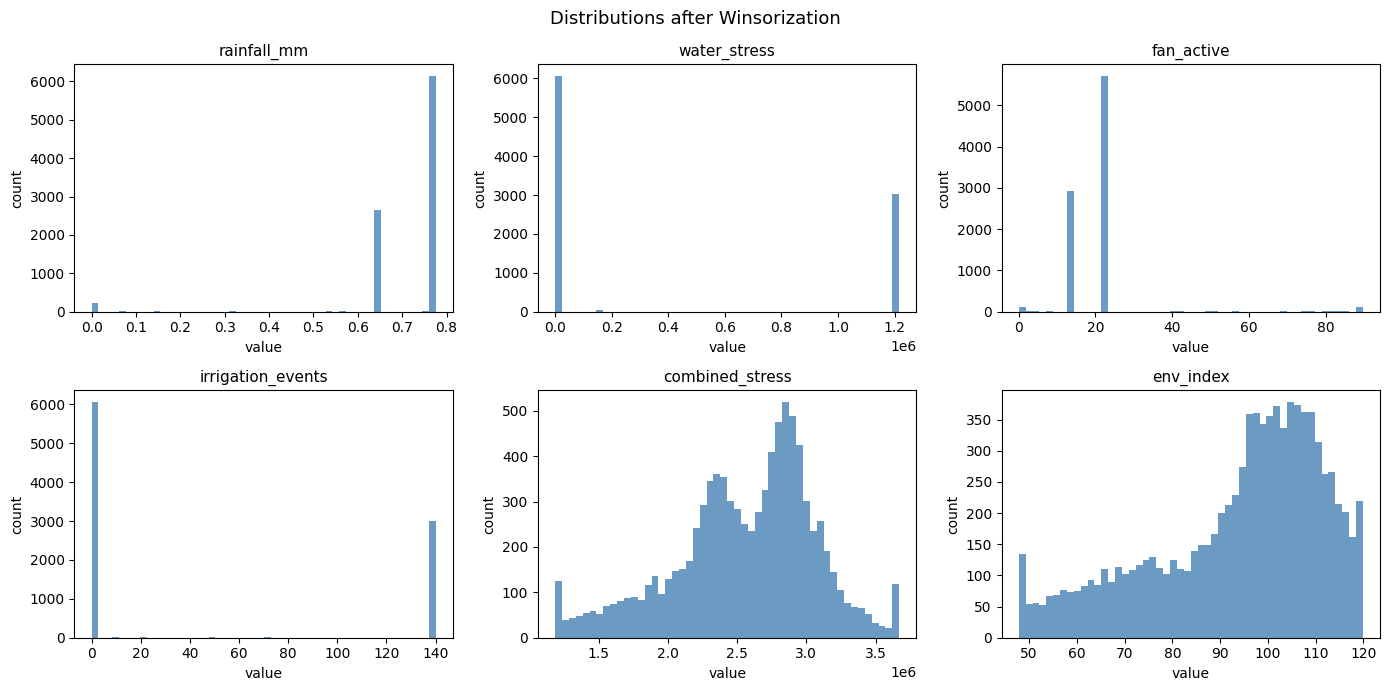

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

plot_cols = ['rainfall_mm', 'water_stress', 'fan_active',
             'irrigation_events', 'combined_stress', 'env_index']

for ax, col in zip(axes, plot_cols):
    ax.hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('value')
    ax.set_ylabel('count')

plt.suptitle('Distributions after Winsorization', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
cs_median = df['combined_stress'].median()
hs_q75    = df['heat_stress'].quantile(0.75)
fr_q75    = df['fungal_risk'].quantile(0.75)

print(f"combined_stress  median : {cs_median:.4f}")
print(f"heat_stress      p75    : {hs_q75:.4f}")
print(f"fungal_risk      p75    : {fr_q75:.4f}")

df['target'] = (
    (df['combined_stress'] > cs_median) |
    (df['heat_stress']     > hs_q75)    |
    (df['fungal_risk']     > fr_q75)
).astype(int)

print("\nNew target distribution:")
print(df['target'].value_counts())
print(f"\nClass balance: {df['target'].mean():.2%} stressed")

combined_stress  median : 2638000.0000
heat_stress      p75    : 1.1835
fungal_risk      p75    : 46.4960

New target distribution:
target
1    5350
0    3782
Name: count, dtype: int64

Class balance: 58.59% stressed


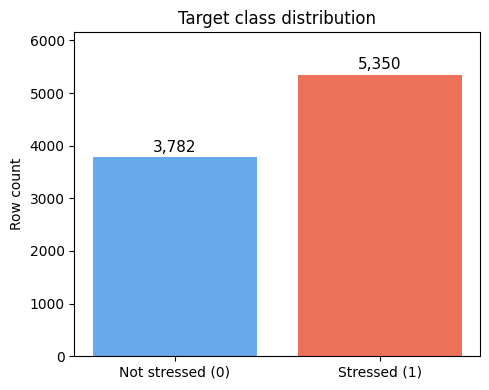

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['target'].value_counts().sort_index()
bars = ax.bar(['Not stressed (0)', 'Stressed (1)'],
               counts.values,
               color=['#4C9BE8', '#E8593C'], edgecolor='none', alpha=0.85)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{count:,}', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Row count')
ax.set_title('Target class distribution')
ax.set_ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()

In [15]:
assert df.isnull().sum().sum() == 0, "Missing values found!"
assert df.duplicated().sum() == 0, "Duplicates found!"
assert df['target'].nunique() == 2, "Target is still constant!"

remaining_frozen = [c for c in df.columns if c != 'target' and df[c].std() < 1e-10]
print(f"Missing values        : {df.isnull().sum().sum()}")
print(f" Duplicates            : {df.duplicated().sum()}")
print(f" Shape                 : {df.shape}")
print(f" Target classes        : {sorted(df['target'].unique().tolist())}")
print(f" Frozen cols remaining : {remaining_frozen}")

Missing values        : 0
 Duplicates            : 0
 Shape                 : (9132, 30)
 Target classes        : [0, 1]
 Frozen cols remaining : []


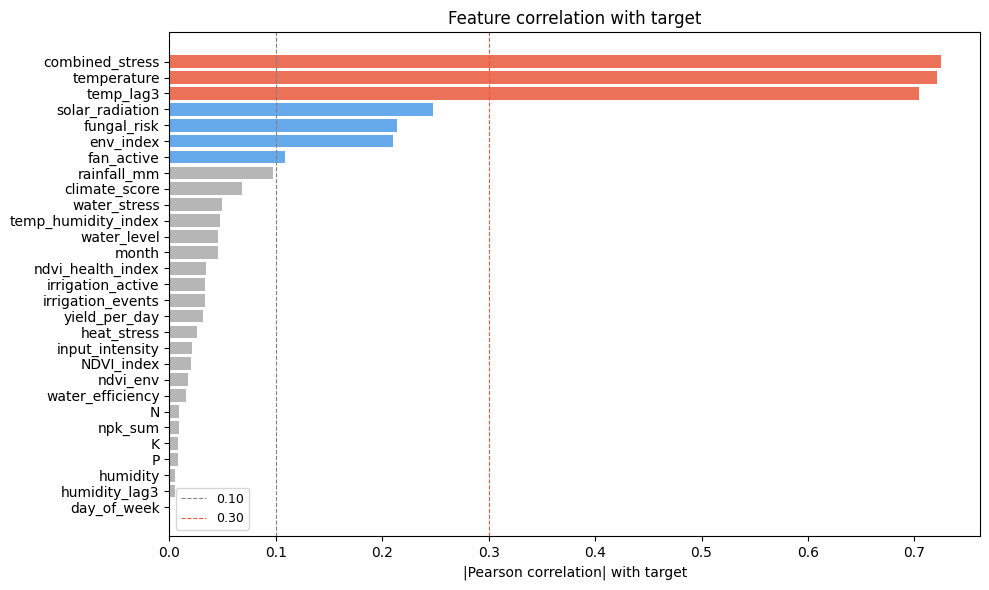


Top 10 features by |correlation with target|:
combined_stress    0.725410
temperature        0.720920
temp_lag3          0.703970
solar_radiation    0.247613
fungal_risk        0.213785
env_index          0.210344
fan_active         0.108982
rainfall_mm        0.097649
climate_score      0.068318
water_stress       0.049151


In [16]:
corr = df.corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E8593C' if v > 0.3 else '#4C9BE8' if v > 0.1 else '#AAAAAA'
          for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1],
        color=colors[::-1], edgecolor='none', alpha=0.85)
ax.axvline(0.1, color='gray', linestyle='--', linewidth=0.8, label='0.10')
ax.axvline(0.3, color='#E8593C', linestyle='--', linewidth=0.8, label='0.30')
ax.set_xlabel('|Pearson correlation| with target')
ax.set_title('Feature correlation with target')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 features by |correlation with target|:")
print(corr.head(10).to_string())

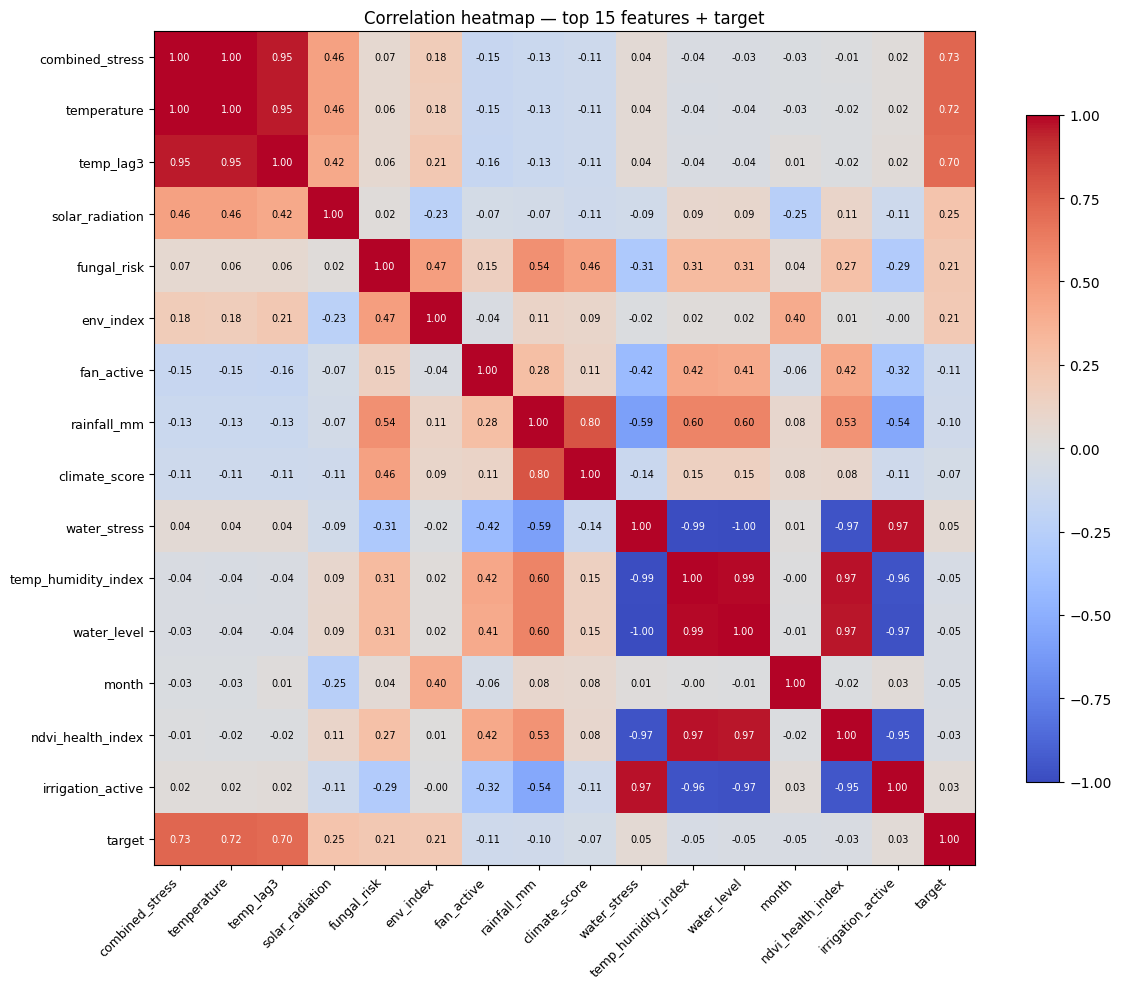

In [17]:
top_features = corr.head(15).index.tolist() + ['target']
corr_matrix  = df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(top_features)))
ax.set_yticks(range(len(top_features)))
ax.set_xticklabels(top_features, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(top_features, fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation heatmap — top 15 features + target', fontsize=12)
for i in range(len(top_features)):
    for j in range(len(top_features)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(val) < 0.7 else 'white')
plt.tight_layout()
plt.show()

In [18]:
for i, c in enumerate(df.columns, 1):
    role = 'TARGET' if c == 'target' else 'feature'
    print(f"  {i:2d}. {c:40s}  [{role}]")

   1. temperature                               [feature]
   2. humidity                                  [feature]
   3. solar_radiation                           [feature]
   4. rainfall_mm                               [feature]
   5. water_level                               [feature]
   6. N                                         [feature]
   7. P                                         [feature]
   8. K                                         [feature]
   9. npk_sum                                   [feature]
  10. temp_humidity_index                       [feature]
  11. water_stress                              [feature]
  12. fan_active                                [feature]
  13. irrigation_active                         [feature]
  14. irrigation_events                         [feature]
  15. NDVI_index                                [feature]
  16. yield_per_day                             [feature]
  17. climate_score                             [feature]
  18. water_ef

In [19]:
df.to_csv('../Dataset/processed/final_dataset_preprocessed.csv', index=False)

print("=" * 58)
print("  PREPROCESSING SUMMARY")
print("=" * 58)
print(f"  Rows                : 9,132  (0 dropped)")
print(f"  Columns original    : 52")
print(f"  Columns dropped     : {52 - df.shape[1]}  (frozen artefacts)")
print(f"  Columns final       : {df.shape[1]}")
print()
print("  Fixes applied:")
print("     22 frozen agro columns dropped")
print("     220 negative rainfall values clipped to 0")
print("     Negative fungal_risk clipped to 0")
print("     7 columns Winsorized at 1st/99th percentile")
print("     Target reconstructed from stress signal columns")
print()
vc = df['target'].value_counts().sort_index()
for k, v in vc.items():
    print(f"  Class {k}: {v:,}  ({v/len(df)*100:.1f}%)")
print()
print(f"  Saved → final_dataset_preprocessed.csv")
print("=" * 58)

  PREPROCESSING SUMMARY
  Rows                : 9,132  (0 dropped)
  Columns original    : 52
  Columns dropped     : 22  (frozen artefacts)
  Columns final       : 30

  Fixes applied:
     22 frozen agro columns dropped
     220 negative rainfall values clipped to 0
     Negative fungal_risk clipped to 0
     7 columns Winsorized at 1st/99th percentile
     Target reconstructed from stress signal columns

  Class 0: 3,782  (41.4%)
  Class 1: 5,350  (58.6%)

  Saved → final_dataset_preprocessed.csv
